# Scenario B1: Multiple Suppliers — No REC (Net Generators)

**Description:** Two independent suppliers, no REC. Participants are split
across two balancing groups reflecting real-world supplier competition.
Prosumers are modelled as **net generators** (RES only, no local load).

**Participant–supplier assignment:**
| Supplier / BG | Participants |
|---|---|
| SUP_A / BG_A | prosumer_001 (Fire Station) · consumer_001–004 |
| SUP_B / BG_B | prosumer_002 · prosumer_003 · consumer_005 (Bank) · consumer_006 |

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 2 — SUP_A, SUP_B |
| Balancing Groups | 2 — BG_A (5 participants), BG_B (4 participants) |
| RECs | None |
| Prosumer type | **Net generator** (RES only, no local load) |
| Battery | None |

**Research role:** Tests whether supplier fragmentation alone (without a REC)
changes imbalance costs and supplier revenue, compared to the single-supplier
baseline A1.

**Comparison pairs (net-generator track):**
- B1 vs A1 → effect of multi-supplier competition (no REC)
- B1 vs B2 → incremental value of adding a cross-supplier REC
- B1 vs B2-forecasts → REC value under explicit forecast scheduling

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [1]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [2]:
CONFIG_FILE = "B1_multiple_supplier_no_rec.json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="B1")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts (per BG)
2. **Intra-Day Market** - Adjust positions with updated ID forecasts (per BG)
3. **REC Settlement** - (Skipped for B1 - no REC configured)
4. **Balancing Market** - Settle imbalances at dual pricing (per BG)
5. **Supplier Billing** - Calculate final costs per participant

In [3]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: B1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: B1
  System  : Multiple Suppliers without REC - Scenario B1
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 2
  Prosumers    : 3
  Consumers    : 6
  RECs         : 0  →  has_rec = False
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 6)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 6)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (70272, 8)
✓ ID market : (70272, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: SKIPPED (no RECs in config)
✓ Balancing market: (70272, 27)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly aggregation: (24, 26)
✓ Profit/loss calculated

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for each supplier.

In [4]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – B1

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €       74.50
      Balancing Rewards   : €       38.74
      Retail Sales        : €   13,537.81
      ────────────────────────────────────────────
      Total Revenue       : €   13,651.05

    COSTS:
      Market Purchases    : €    1,839.71
      Balancing Penalties  : €       36.59
      Retail Purchases     : €    1,439.13
      ────────────────────────────────────────────
      Total Costs          : €    3,315.44

    PROFIT/LOSS:
      Annual Total         : €   10,335.61
      Monthly Average      : €      861.30

    IMBALANCE:
      System Position      : LONG
      Total Imbalance      :        -0.01 MWh
      BG Actual Position   :        49.89 MWh
      BG Forecast Position :        49.89 MWh

  SUP_B (Supplier B):

    REVENUES:
      Energy Market Sales : €      343.35
      Balancing Rewards   : €       58.44
      Retail Sales        : €   16,276.49
      ──────────────

## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

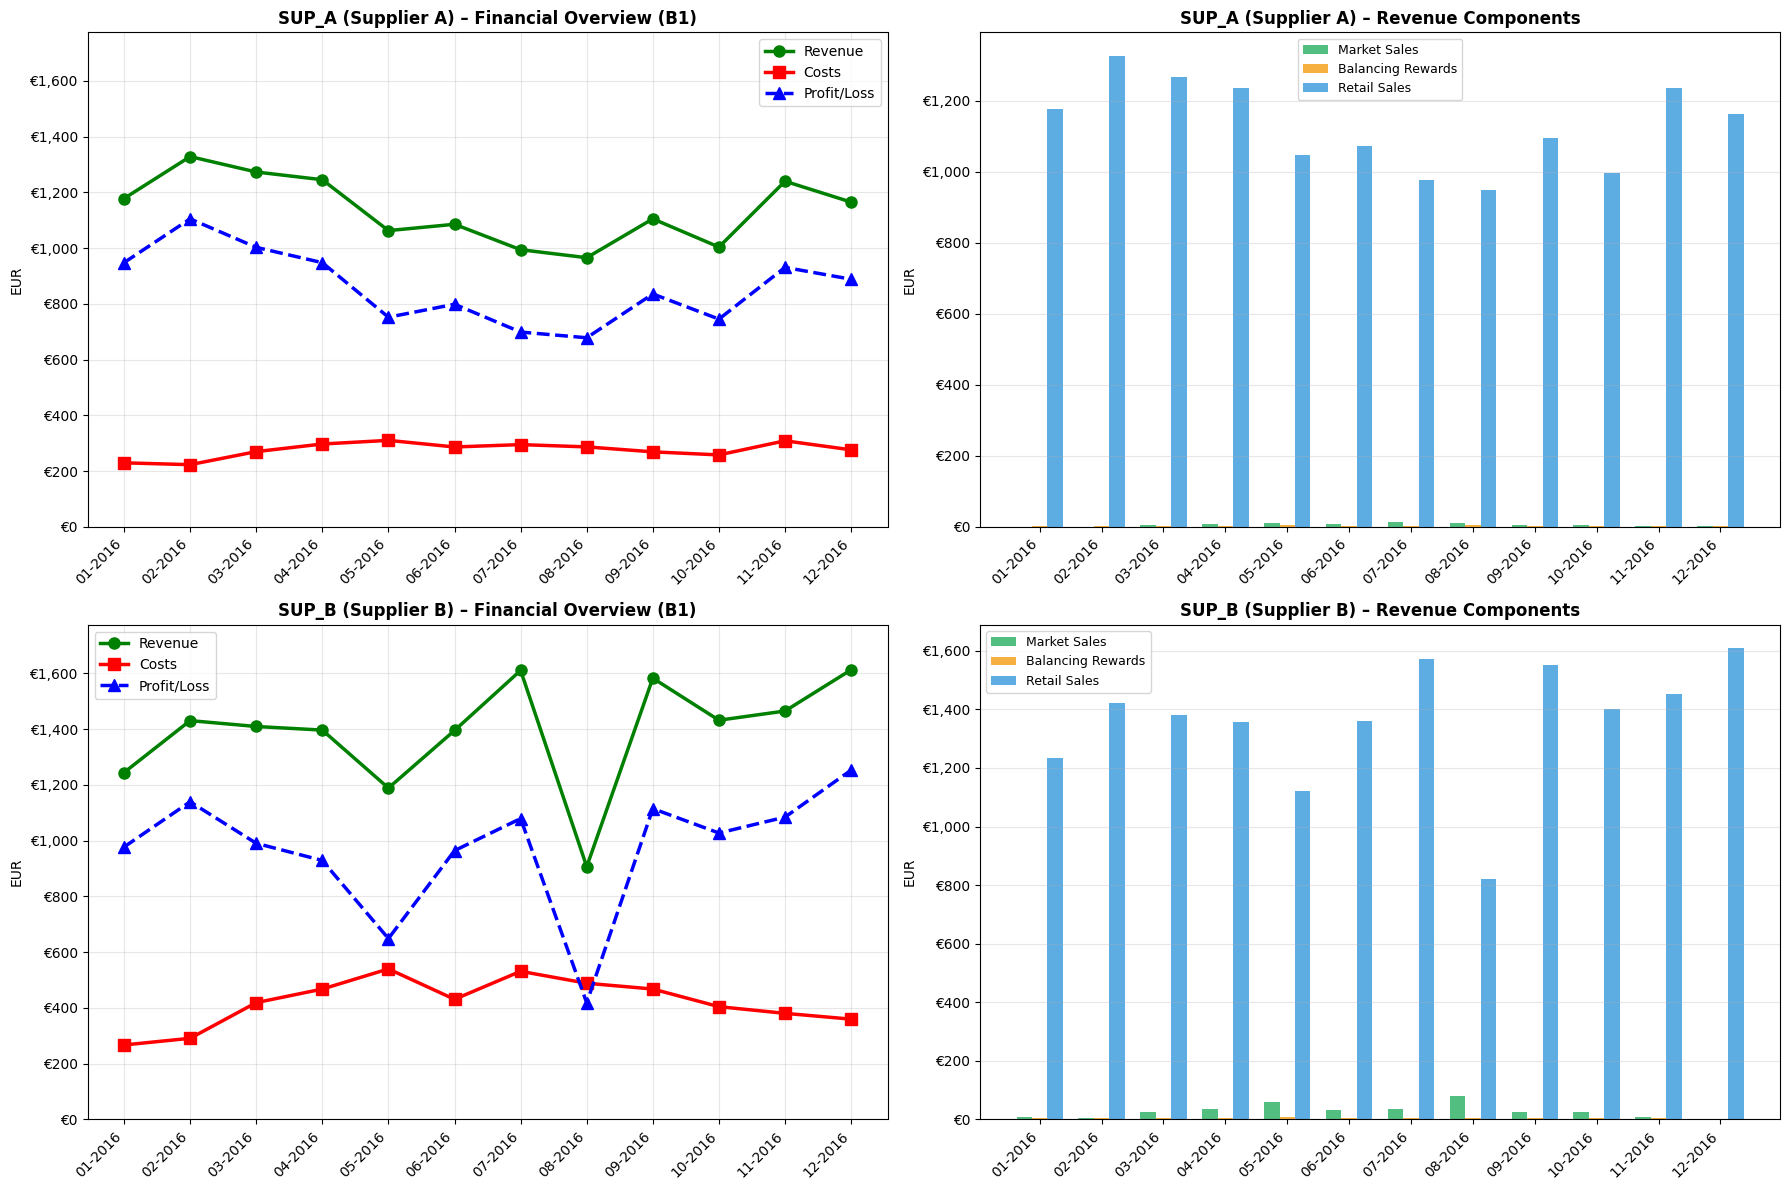

In [5]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

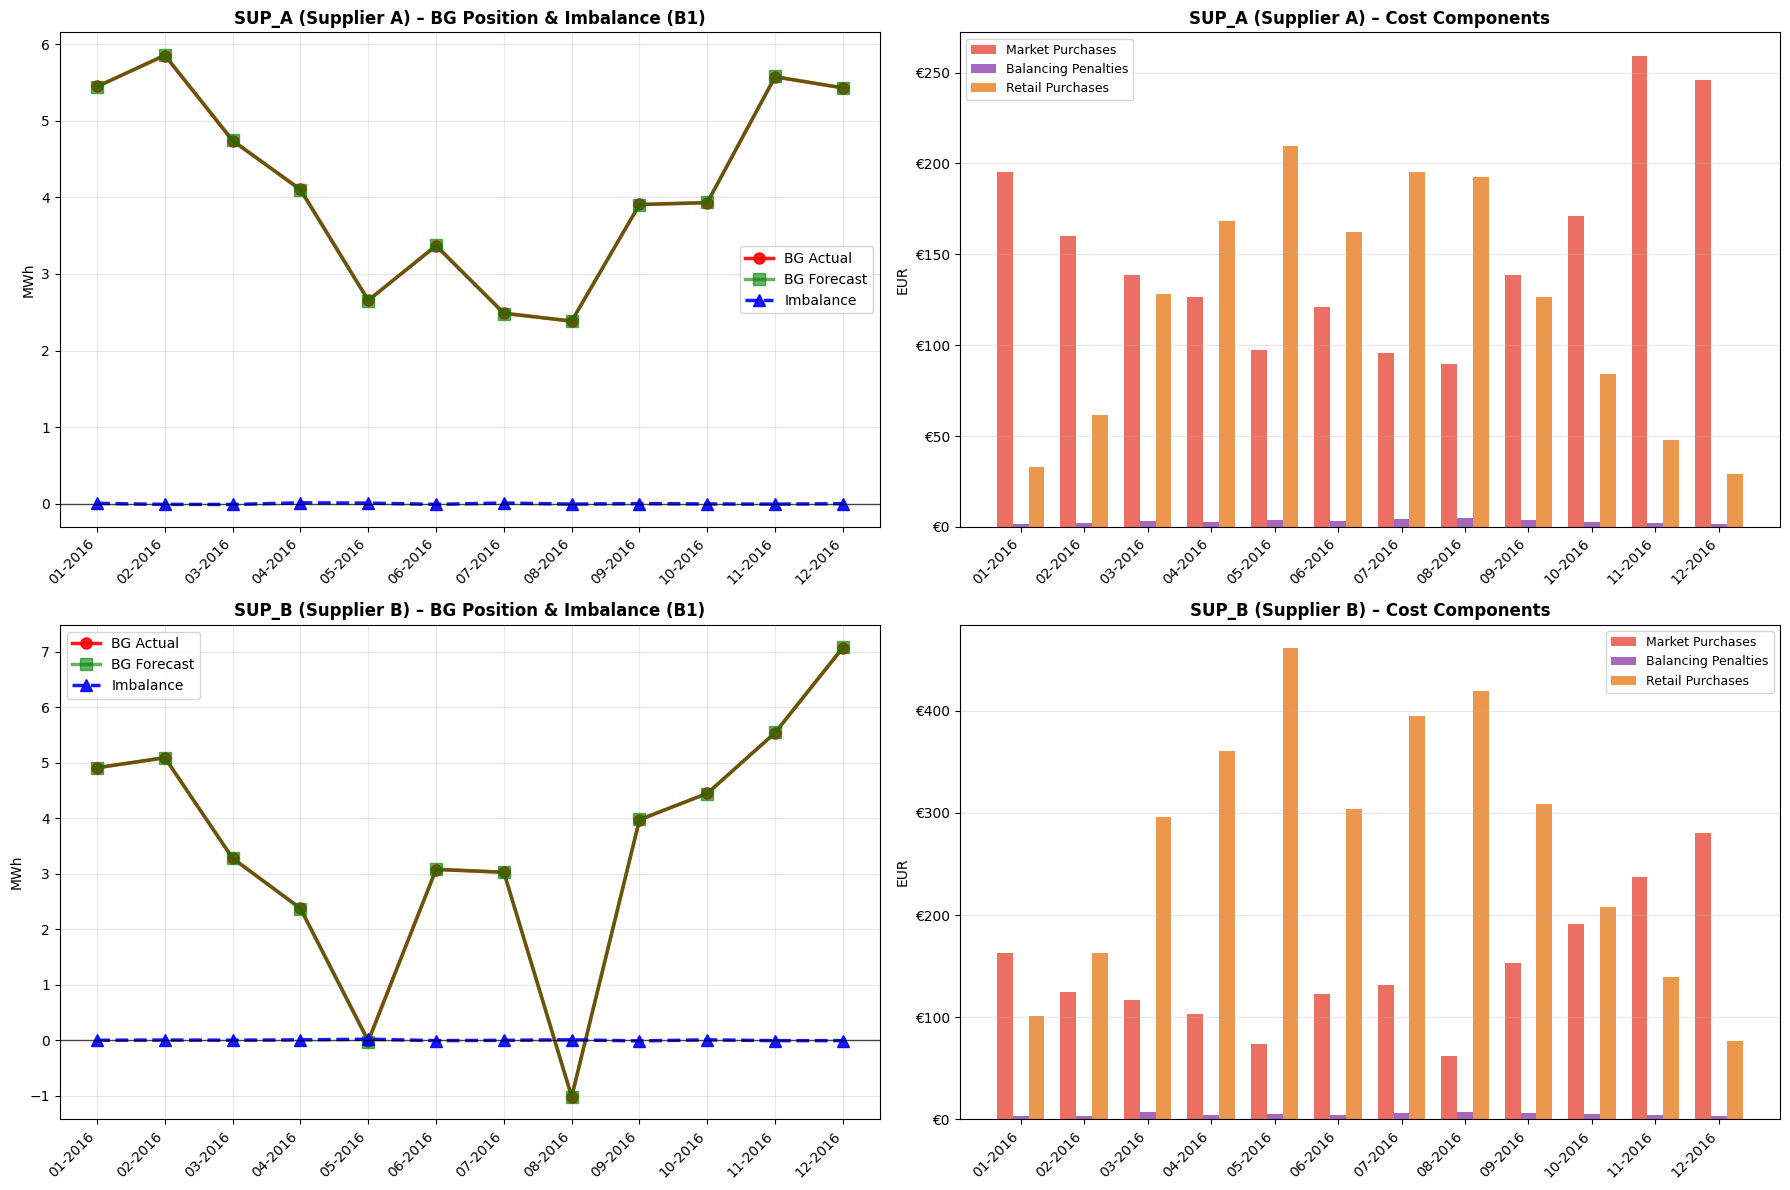

In [6]:
pipe.plot_imbalances()

## 7. Supplier Comparison
Compare financial performance across the two suppliers (SUP_A, SUP_B).

In [7]:
pipe.es_monthly_analysis_df.groupby('supplier_id').agg({
    'total_revenue_eur': 'sum',
    'total_costs_eur': 'sum',
    'profit_loss_eur': 'sum',
    'imbalance_mwh': 'sum'
})

,total_revenue_eur,total_costs_eur,profit_loss_eur,imbalance_mwh
supplier_id,,,,
SUP_A,13651.048642,3315.438322,10335.610320,-0.006901
SUP_B,16678.271445,5049.525957,11628.745488,0.014380
